In [2]:
import importlib
import os
import pickle
from pathlib import Path
import re

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from behave_analysis.visualize.visualize_utils import open_tracking_data
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.analyze.single_trial import preprocess_regression
from behave_analysis.analyze.single_trial import single_trial_regression
from behave_analysis.analyze.single_trial.single_trial_regression import SingleTrialRegression
from behave_analysis.analyze.single_trial.preprocess_regression import PreprocessSingleTrialRegression
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_shelt_4mar


# Sessions to consider

In [3]:
# JAL6
#experiments_objects = [JAL6_shelt_4mar, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar]
#experiments_objects = [JAL6_flip4_21mar]
experiments_objects = [JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar]



In [4]:
c_type = "good"
dir = make_directory(r"Z:\Jasmine_Laurence\single_trial_overview")
dir = Path(dir)

# Loop through sessions and generate R2 scores across all homings all conditions

In [5]:
#session_names = ["JAL6_21st_March"]
#session_names = ["JAL6_4th_March", "JAL6_18th_March", "JAL6_21st_March", "JAL6_25th_March", "JAL6_28th_March"]
session_names = ["JAL6_18th_March", "JAL6_21st_March", "JAL6_25th_March", "JAL6_28th_March"]

In [5]:
importlib.reload(preprocess_regression)
importlib.reload(single_trial_regression)

for i, session in enumerate(experiments_objects):
    
    # Get the session
    loaded_session = get_experiment(session)
    
    # Define paths
    video_and_spike_data_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "good_video_spike_count_df.parquet")
    homing_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "homings", "homings_obj.pkl")
    escape_path = os.path.join(loaded_session.base_path, loaded_session.processed_path, "escapes", "escapes_obj.pkl")

    # Load data
    try:
        video_df = pl.read_csv(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" "full_video_dataframe.csv")
        with open(homing_path, "rb") as hf:
                homings_object = pickle.load(hf)
        video_and_spike_data = pl.read_parquet(video_and_spike_data_path)
        frame_by_cluster_matrix = np.load(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" + "frame_by_" + c_type + "_cluster_matrix.npy")
        tracking_data = open_tracking_data(loaded_session)
        with open(escape_path, "rb") as ef:
                escape_object = pickle.load(ef)
        cluster_Ids = np.load(str(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "/" + c_type + "_cluster_Ids.npy"))
    
    except FileNotFoundError:
        print("One of the files was not found")
    
    # Check if the homing object has the expected keys
    finally:
        angle_data = homings_object.homing_angles_dic
        expected_keys = ["avg_pre_flip_head_angle", "avg_post_flip_head_angle", "avg_hsa"]
        assert all(key in angle_data.keys() for key in expected_keys), "The keys are not as expected in the homing angle data, please regenerate the homing object"
    
    # Run analysis
    pp_single_trial_obj = PreprocessSingleTrialRegression(
        video_df=video_df,
        homings_obj=homings_object,
        video_and_spike_data=video_and_spike_data,
        frame_by_cluster_matrix=frame_by_cluster_matrix,
        save_path=dir,
        velocity_data=tracking_data["avg_Velocity"],
        similar_homings=False,
        barrier_location=tracking_data["barrier_loc"],
        shelter_location=tracking_data["shelter_loc"],
        escape_object=escape_object,
        remove_escapes=False,
        save_plots=False)
    
    
                    
    SingleTrialRegression(
        design_matrix=pp_single_trial_obj.design_matrix,
        save_path=dir,
        dependents_df=pp_single_trial_obj.targets_df,
        tracking_data=tracking_data,
        homing_list=pp_single_trial_obj.homing_list,
        spike_homing_list=pp_single_trial_obj.spike_data_per_homing,
        condition_per_homing=pp_single_trial_obj.condition_per_homing,
        cluster_ids=cluster_Ids,
        initial_directions=pp_single_trial_obj.initial_directions,
        conversion_from_left_right_to_pre_post_flip=pp_single_trial_obj.convert_left_right_to_pre_post_flip,
        session_name=session_names[i])
            

2024-09-02 15:09:44.448 | INFO     | behave_analysis.analyze.single_trial.preprocess_regression:__init__:53 - Initializing the single trial regression preprocessing object
2024-09-02 15:09:44.449 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:15 - The barrier location pre flip is [224, 515] and post flip is [797, 512]
2024-09-02 15:09:44.450 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:17 - The barrier preflip location is the left edge
2024-09-02 15:09:44.640 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:15 - The barrier location pre flip is [224, 515] and post flip is [797, 512]
2024-09-02 15:09:44.641 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:17 - The barrier preflip location is the left edge
2024-09-02 15:09:44.647 | SUCCESS  | behave_analysis.ana

Running the model for the dependent variable: pre_flip_index
Running the model with neural_data added to the model. (Neural data is not added twice)
Running the model with frames added to the model. (Neural data is not added twice)
Running the model with mouse_x_position added to the model. (Neural data is not added twice)
Running the model with mouse_y_position added to the model. (Neural data is not added twice)
Running the model with hdir added to the model. (Neural data is not added twice)
Running the model with hsa added to the model. (Neural data is not added twice)
Running the model with h_preflipbar_a added to the model. (Neural data is not added twice)
Running the model with h_postflipbar_a added to the model. (Neural data is not added twice)
Running the model with homing_id added to the model. (Neural data is not added twice)
Running the model with post_flip_index added to the model. (Neural data is not added twice)
Running the model with velocity added to the model. (Neural 

2024-09-02 15:18:45.113 | SUCCESS  | behave_analysis.analyze.single_trial.single_trial_regression:run:185 - The model has been run for the hierarchical regression
2024-09-02 15:18:45.114 | SUCCESS  | behave_analysis.analyze.single_trial.single_trial_regression:__init__:100 - The single trial analysis has completed for a single session
2024-09-02 15:20:28.773 | INFO     | behave_analysis.analyze.single_trial.preprocess_regression:__init__:53 - Initializing the single trial regression preprocessing object
2024-09-02 15:20:28.794 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:15 - The barrier location pre flip is [216, 515] and post flip is [809, 508]
2024-09-02 15:20:28.796 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:17 - The barrier preflip location is the left edge
2024-09-02 15:20:28.987 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_locati

Running the model for the dependent variable: pre_flip_index
Running the model with neural_data added to the model. (Neural data is not added twice)
Running the model with frames added to the model. (Neural data is not added twice)
Running the model with mouse_x_position added to the model. (Neural data is not added twice)
Running the model with mouse_y_position added to the model. (Neural data is not added twice)
Running the model with hdir added to the model. (Neural data is not added twice)
Running the model with hsa added to the model. (Neural data is not added twice)
Running the model with h_preflipbar_a added to the model. (Neural data is not added twice)
Running the model with h_postflipbar_a added to the model. (Neural data is not added twice)
Running the model with homing_id added to the model. (Neural data is not added twice)
Running the model with post_flip_index added to the model. (Neural data is not added twice)
Running the model with velocity added to the model. (Neural 

2024-09-02 15:27:07.905 | SUCCESS  | behave_analysis.analyze.single_trial.single_trial_regression:run:185 - The model has been run for the hierarchical regression
2024-09-02 15:27:07.906 | SUCCESS  | behave_analysis.analyze.single_trial.single_trial_regression:__init__:100 - The single trial analysis has completed for a single session
2024-09-02 15:28:08.834 | INFO     | behave_analysis.analyze.single_trial.preprocess_regression:__init__:53 - Initializing the single trial regression preprocessing object
2024-09-02 15:28:08.835 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:15 - The barrier location pre flip is [804, 511] and post flip is [220, 511]
2024-09-02 15:28:08.836 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:20 - The barrier preflip location is the right edge
2024-09-02 15:28:09.009 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_locat

Running the model for the dependent variable: pre_flip_index
Running the model with neural_data added to the model. (Neural data is not added twice)
Running the model with frames added to the model. (Neural data is not added twice)
Running the model with mouse_x_position added to the model. (Neural data is not added twice)
Running the model with mouse_y_position added to the model. (Neural data is not added twice)
Running the model with hdir added to the model. (Neural data is not added twice)
Running the model with hsa added to the model. (Neural data is not added twice)
Running the model with h_preflipbar_a added to the model. (Neural data is not added twice)
Running the model with h_postflipbar_a added to the model. (Neural data is not added twice)
Running the model with homing_id added to the model. (Neural data is not added twice)
Running the model with post_flip_index added to the model. (Neural data is not added twice)
Running the model with velocity added to the model. (Neural 

2024-09-02 15:35:08.217 | SUCCESS  | behave_analysis.analyze.single_trial.single_trial_regression:run:185 - The model has been run for the hierarchical regression
2024-09-02 15:35:08.218 | SUCCESS  | behave_analysis.analyze.single_trial.single_trial_regression:__init__:100 - The single trial analysis has completed for a single session
2024-09-02 15:35:42.277 | INFO     | behave_analysis.analyze.single_trial.preprocess_regression:__init__:53 - Initializing the single trial regression preprocessing object
2024-09-02 15:35:42.278 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:15 - The barrier location pre flip is [227, 517] and post flip is [809, 516]
2024-09-02 15:35:42.279 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_location_is_which_orientation:17 - The barrier preflip location is the left edge
2024-09-02 15:35:42.465 | INFO     | behave_analysis.utils.label_barrier_edges:check_which_barrier_locati

Running the model for the dependent variable: pre_flip_index
Running the model with neural_data added to the model. (Neural data is not added twice)
Running the model with frames added to the model. (Neural data is not added twice)
Running the model with mouse_x_position added to the model. (Neural data is not added twice)
Running the model with mouse_y_position added to the model. (Neural data is not added twice)
Running the model with hdir added to the model. (Neural data is not added twice)
Running the model with hsa added to the model. (Neural data is not added twice)
Running the model with h_preflipbar_a added to the model. (Neural data is not added twice)
Running the model with h_postflipbar_a added to the model. (Neural data is not added twice)
Running the model with homing_id added to the model. (Neural data is not added twice)
Running the model with post_flip_index added to the model. (Neural data is not added twice)
Running the model with velocity added to the model. (Neural 

2024-09-02 15:41:55.606 | SUCCESS  | behave_analysis.analyze.single_trial.single_trial_regression:run:185 - The model has been run for the hierarchical regression
2024-09-02 15:41:55.607 | SUCCESS  | behave_analysis.analyze.single_trial.single_trial_regression:__init__:100 - The single trial analysis has completed for a single session


# Load the adjusted r2s and plot

In [ ]:
load_dir = r"Z:\Jasmine_Laurence\single_trial_overview\adjusted_r2_scores"
# Initialize an empty list to store the extracted parts of the filenames
file_names = []
r2_data = {}

# Loop through the files in the directory
for file in os.listdir(load_dir):
    
    # Use regex to extract everything before '_r2'
    match = re.match(r'^(.*)_post', file)
    extracted_part = None
    if match:
        extracted_part = match.group(1)
        file_names.append(extracted_part)
        
    # Load the .pickle files
    if file.endswith(".pickle"):
        with open(os.path.join(load_dir, file), "rb") as f:
            data = pickle.load(f)
            r2_data[extracted_part] = data

# Use session names to sort the dictionary
sorted_r2_data = {k: r2_data[k] for k in session_names}

# Print the extracted filenames
df = pd.DataFrame.from_dict(sorted_r2_data, orient="index")

In [ ]:
df

In [ ]:
r2_bump = np.diff(df, axis=1)
print(r2_bump)
column_names = df.columns[1:]
print(column_names)
new_df = pd.DataFrame(r2_bump, columns=column_names, index=df.index)
print(new_df)

# Remove JAL6_4th_March
#new_df = new_df.drop("JAL6_4th_March")

In [ ]:
new_df

In [ ]:
#neural_r2_scores = df.drop("JAL6_4th_March")
neural_r2_scores = df["neural_data"]
print(neural_r2_scores.values)

In [ ]:
# Reusing new_df and session_names from previous code
# Plotting the stacked bar chart with allowance for negative values
fig, ax1 = plt.subplots(figsize=(10, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(new_df.columns)))

for si, session in enumerate(session_names):
    bottom_positive = 0
    bottom_negative = 0
    for i, (column, value) in enumerate(new_df.iloc[si].items()):
        if value >= 0:
            bar = ax1.bar(session, value, bottom=bottom_positive, label=column if si == 0 else "", color=colors[i])
            ax1.text(bar[0].get_x() + bar[0].get_width() / 2, bottom_positive + value / 2, f'{value:.5f}', 
                    ha='center', va='center', color='black')
            bottom_positive += value
        else:
            bar = ax1.bar(session, value, bottom=bottom_negative, label=column if si == 0 else "", color=colors[i])
            ax1.text(bar[0].get_x() + bar[0].get_width() / 2, bottom_negative + value / 2, f'{value:.5f}', 
                    ha='center', va='center', color='black')
            bottom_negative += value

ax1.set_ylabel('Increase in Adjusted R2 when adding this variable')
ax1.set_title("Adjusted R2 scores for a hierarchical regression model decoding the post_flip_index during homings")

# Adding a second y-axis for the R2 score
ax2 = ax1.twinx()
ax2.plot(session_names, neural_r2_scores.values, color='red', marker='x', label='neural R2', alpha=0.5)
ax2.set_ylabel('Neural R2 Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Set the y-axis limits
ax2.set_ylim(0, 1)

# Draw a horizontal line at 0
ax1.axhline(0, color='black', lw=0.5)

# Show the legend only once
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1[:len(new_df.columns)], labels1[:len(new_df.columns)], bbox_to_anchor=(1.2, 1), loc='upper left')
ax2.legend(handles2, labels2, bbox_to_anchor=(1, 0.9), loc='upper left')

plt.tight_layout()
plt.show()

# Load mutual information

In [6]:
var = "_pre_flip_index_mutual"

In [7]:
load_dir = r"Z:\Jasmine_Laurence\single_trial_overview\adjusted_r2_scores"
# Initialize an empty list to store the extracted parts of the filenames
file_names = []
r2_data = {}

# Loop through the files in the directory
for file in os.listdir(load_dir):
    
    # Use regex to extract everything before '_r2'
    match = re.match(rf'^(.*){var}', file)
    extracted_part = None
    if match:
        extracted_part = match.group(1)
        file_names.append(extracted_part)
        
    # Load the .pickle files
    if file.endswith(".pickle"):
        with open(os.path.join(load_dir, file), "rb") as f:
            data = pickle.load(f)
            r2_data[extracted_part] = data

# Use session names to sort the dictionary
sorted_r2_data = {k: r2_data[k] for k in session_names}

# Print the extracted filenames
df = pd.DataFrame.from_dict(sorted_r2_data, orient="index")

In [8]:
df = df.T
print(df)

                                                   JAL6_18th_March  \
neural_mi        [0.048149501757440705, 0.12245147203180373, 0....   
task_related_mi       frames  mouse_x_position  mouse_y_positio...   

                                                   JAL6_21st_March  \
neural_mi        [0.06876916869253424, 0.03566637996074706, 0.0...   
task_related_mi       frames  mouse_x_position  mouse_y_positio...   

                                                   JAL6_25th_March  \
neural_mi        [0.02157604685287673, 0.019751120373890263, 0....   
task_related_mi       frames  mouse_x_position  mouse_y_positio...   

                                                   JAL6_28th_March  
neural_mi        [0.050083272387050126, 0.1153308257132788, 0.0...  
task_related_mi       frames  mouse_x_position  mouse_y_positio...  


In [52]:
df["JAL6_18th_March"]["neural_mi"]
#print(df.index)
#print(df["JAL6_18th_March"]["task_related_mi"])

data = []
vars = df["JAL6_18th_March"]["task_related_mi"].columns.values
for session in session_names:
    data.append(df[session]["task_related_mi"].values)
    print("Len of: ", len(df[session]["neural_mi"]))

print(data)
print(vars)

Len of:  264
Len of:  266
Len of:  264
Len of:  114
[array([[0.59937222, 0.71891908, 1.57617244, 1.52704064, 0.73754668,
        0.77322887, 0.41448667, 0.4062042 , 1.59067763, 0.33858797,
        0.        ]]), array([[0.52587668, 0.69582562, 1.5938856 , 1.51216858, 0.74438364,
        0.88953999, 0.409164  , 0.40265365, 1.44710115, 0.32155032,
        0.00234019]]), array([[0.61569601, 0.77301109, 1.50097314, 1.4925773 , 0.5903231 ,
        0.61776057, 0.41437811, 0.44522108, 1.41922041, 0.28583176,
        0.        ]]), array([[0.75404804, 0.90003618, 1.65715452, 1.67201162, 0.95674134,
        1.11589757, 0.48912418, 0.34820125, 1.46024807, 0.41853474,
        0.        ]])]
['frames' 'mouse_x_position' 'mouse_y_position' 'hdir' 'hsa'
 'h_preflipbar_a' 'h_postflipbar_a' 'homing_id' 'post_flip_index'
 'velocity' 'random']


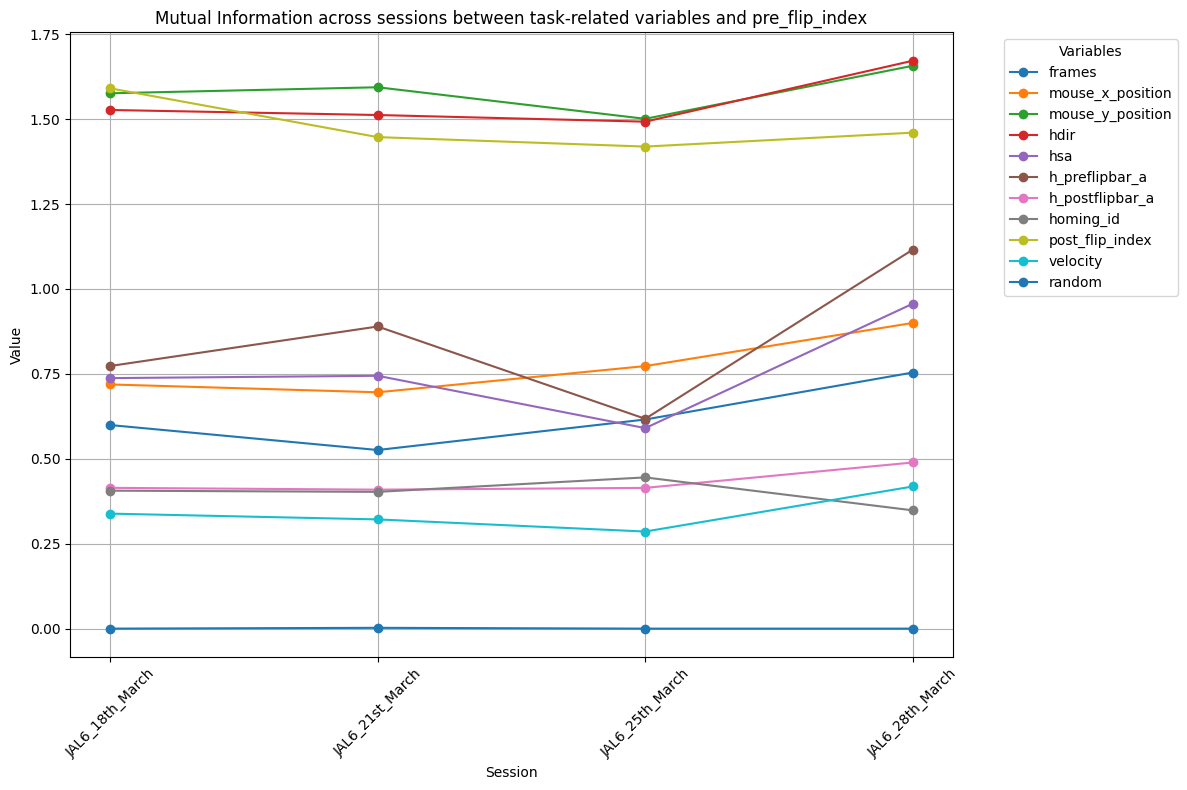

In [50]:
# Convert list of arrays into a 2D numpy array for easier handling
# Shape will be (num_sessions, num_vars)
data = np.concatenate(data, axis=0)

# Number of variables
num_vars = len(vars)

# Number of sessions
num_sessions = len(data)

# Create x-ticks representing each session
xticks = np.arange(num_sessions)

plt.figure(figsize=(12, 8))

# Loop through each variable
for i in range(num_vars):
    # Extract the values for the current variable across all sessions
    y_values = data[:, i]
    
    # Plot the values
    plt.plot(xticks, y_values, marker='o', label=vars[i])

# Labeling the plot
plt.xticks(xticks, [f'{i}' for i in session_names], rotation=45)  # Set session names as x-axis labels
plt.xlabel('Session')
plt.ylabel('Value')
plt.title('Mutual Information across sessions between task-related variables and pre_flip_index')
plt.legend(title="Variables", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

InvalidIndexError: (slice(None, None, None), 0)

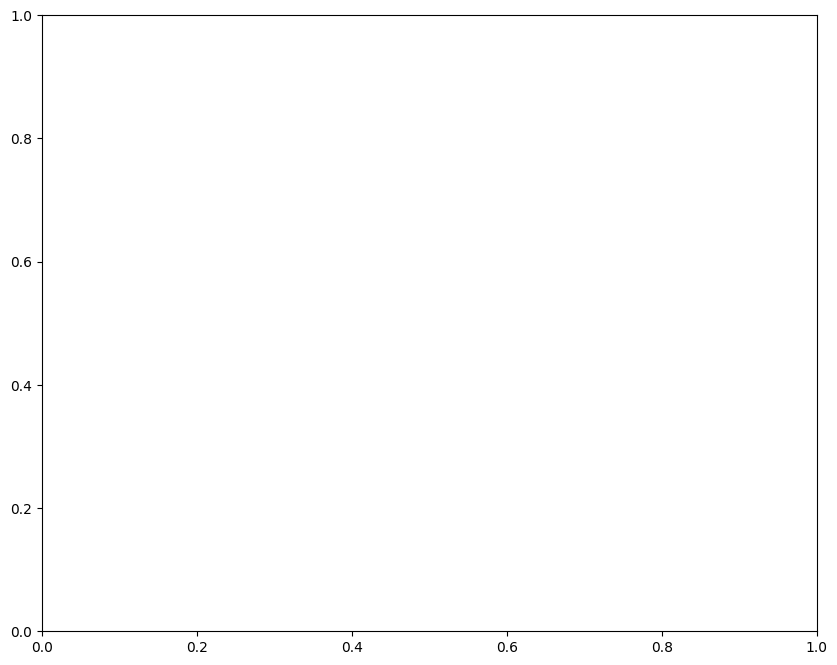

In [22]:
# plot each task relevant MI score
fig, ax = plt.subplots(figsize=(10, 8))
for i, column in enumerate(df.columns):
    data = df[column]["task_related_mi"]
    # plot each column as a line
    for column in range(data.shape[1]):
        ax.scatter(df.index, data[:, column], label=f"task_related_mi_{column}", alpha=0.5)

In [ ]:
plt.figure(figsize=(10, 6))
plt.violinplot([df['JAL6_18th_March'].dropna()[-11:], df['JAL6_21st_March'].dropna()[-11:], df['JAL6_25th_March'].dropna()[-11:], df['JAL6_28th_March'].dropna()[-11:]], showmeans=True)
plt.xticks([1, 2, 3, 4], ['JAL6 18th March', 'JAL6 21st March', 'JAL6 25th March', 'JAL6 28th March'])
plt.title("Violin Plots for March JAL6 Data")
plt.ylabel("NATS")
plt.show()

In [ ]:
# Print the mutual information between HSA  and the pre_flip_index
print(df['JAL6_25th_March'].dropna().values[-7])
print(df['JAL6_28th_March'].dropna().values[-7])
print(df['JAL6_21st_March'].dropna().values[-7])
print(df['JAL6_18th_March'].dropna().values[-7])

In [ ]:
# Print the mutual information between post_flip_index and the pre_flip_index
print(df['JAL6_25th_March'].dropna().values[-3])
print(df['JAL6_28th_March'].dropna().values[-3])
print(df['JAL6_18th_March'].dropna().values[-3])
print(df['JAL6_21st_March'].dropna().values[-3])

In [ ]:
# Print the mutual information between Noise and the pre_flip_index
print(df['JAL6_25th_March'].dropna().values[-1])
print(df['JAL6_28th_March'].dropna().values[-1])
print(df['JAL6_21st_March'].dropna().values[-1])
print(df['JAL6_18th_March'].dropna().values[-1])

In [ ]:
plt.figure(figsize=(10, 6))
plt.violinplot([df['JAL6_18th_March'].dropna()[:-11], df['JAL6_21st_March'].dropna()[:-11], df['JAL6_25th_March'].dropna()[:-11], df['JAL6_28th_March'].dropna()[:-11]], showmeans=True)
plt.xticks([1, 2, 3, 4], ['JAL6 18th March', 'JAL6 21st March', 'JAL6 25th March', 'JAL6 28th March'])
plt.title("Violin Plots for March JAL6 Data")
plt.ylabel("NATS")
plt.show()